# **Text Classification with Trainable Embeddings**

**1. Imports and Reproducibility Setup**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter
import copy  # Important for deep copying initial weights

torch.manual_seed(42)
np.random.seed(42)

**2. Dataset Loading (Training and Test Data)**

In [2]:
# Training texts (100 Sports, 100 Technology)
train_texts = [
    # Sports (Label 0)
    "Lakers win championship after amazing comeback",
    "Football team scores three goals in final match",
    "Tennis star wins grand slam tournament",
    "Olympic athlete breaks world record",
    "Basketball game ends in dramatic overtime",
    "Soccer team advances to finals",
    "Runner wins marathon in record time",
    "Baseball team clinches playoff spot",
    "Swimmer wins gold medal at Olympics",
    "Hockey team defeats rival in shootout",
    "Gymnast performs perfect routine at competition",
    "Boxer wins title fight in final round",
    "Cycling champion wins Tour de France stage",
    "Golfer sinks incredible putt to win tournament",
    "Figure skater lands difficult jump perfectly",
    "Wrestling champion defends title successfully",
    "Cricket team wins test match series",
    "Rugby team scores last minute try",
    "Volleyball team wins championship match",
    "Badminton player wins international tournament",
    "Team celebrates victory after tough game",
    "Players train hard for upcoming season",
    "Coach announces new strategy for playoffs",
    "Stadium packed with fans for final game",
    "Athletes compete in regional championship",
    "Team captain leads squad to victory",
    "Young player shows great potential",
    "Fans celebrate team winning streak",
    "Manager signs new contract with club",
    "Training camp begins for new season",
    "Team wins away game against rivals",
    "Player receives award for performance",
    "Championship game draws huge crowd",
    "Team prepares for important match",
    "Coach praises players after victory",
    "Athletes set new records at event",
    "Team qualifies for next round",
    "Player scores hat trick in match",
    "Championship trophy awarded to winners",
    "Team celebrates historic achievement",
    "Players excited for tournament start",
    "Coach announces starting lineup today",
    "Team practices before big game",
    "Victory parade celebrates championship win",
    "Players sign autographs for fans",
    "Team mascot entertains crowd at game",
    "Championship banner raised at stadium",
    "Team dominates in playoff series",
    "Player injury sidelines star athlete",
    "Team rebuilds roster for season",
    "Coach implements new training program",
    "Players bond during team retreat",
    "Stadium renovations completed for season",
    "Team announces ticket prices for games",
    "Player traded to rival team",
    "Coach resigns after disappointing season",
    "Team practices penalty kicks for game",
    "Championship ring ceremony held today",
    "Team wins tournament in overtime",
    "Player breaks scoring record in game",
    "Coach gives motivational speech to team",
    "Team celebrates winning season finale",
    "Athletes train for upcoming competition",
    "Player signs endorsement deal today",
    "Team unveils new uniform design",
    "Championship parade draws massive crowd",
    "Coach analyzes game film with players",
    "Team defeats defending champions convincingly",
    "Player receives sportsmanship award today",
    "Team holds charity event for fans",
    "Athletes prepare for championship match",
    "Coach praises team effort after win",
    "Team advances in tournament bracket",
    "Player scores winning goal in match",
    "Championship celebrations continue all week",
    "Team announces preseason schedule today",
    "Players work hard during practice",
    "Coach happy with team performance",
    "Team wins decisive game at home",
    "Athletes excited for season opener",
    "Player makes incredible save in game",
    "Team rallies from behind for victory",
    "Coach confident before important match",
    "Championship run inspires young athletes",
    "Team prepares strategy for rivals",
    "Player demonstrates leadership on field",
    "Team celebrates milestone victory today",
    "Coach reviews tactics with players",
    "Athletes compete in regional finals",
    "Player achieves personal best in event",
    "Team practices formations for game",
    "Championship trophy displayed at stadium",
    "Coach motivates team before playoffs",
    "Team wins thrilling match in finale",
    "Player earns spot on national team",
    "Athletes train for international competition",
    "Team holds press conference today",

    # Technology (Label 1)
    "New smartphone features advanced AI technology",
    "Tech company releases latest software update",
    "Scientists develop breakthrough quantum computer",
    "Artificial intelligence system improves healthcare",
    "New app helps users learn programming",
    "Electric vehicle company announces new model",
    "Researchers create faster internet connection",
    "Social media platform adds new features",
    "Cloud computing service expands globally",
    "Cybersecurity system protects against attacks",
    "Virtual reality headset launches next month",
    "Machine learning algorithm solves complex problem",
    "New programming language released by developers",
    "Tech startup raises millions in funding",
    "5G network expands to more cities",
    "Robotics company builds autonomous system",
    "Data center uses renewable energy",
    "Blockchain technology improves security",
    "New laptop features powerful processor",
    "Software update fixes major bugs",
    "Company develops innovative tech solution",
    "Algorithm improves search accuracy online",
    "Digital platform streamlines business operations",
    "Innovation drives tech industry forward",
    "Startup creates app for education",
    "Computer chip breakthrough announced today",
    "Technology advances medical research capabilities",
    "New software helps developers code faster",
    "Tech firm invests in AI research",
    "Digital transformation changes business landscape",
    "Scientists program robot for tasks",
    "Tech company expands into new markets",
    "Innovation lab opens in Silicon Valley",
    "New technology revolutionizes communication industry",
    "Software engineers develop better tools",
    "Tech conference showcases latest innovations",
    "Startup creates platform for collaboration",
    "Computer vision system recognizes objects accurately",
    "Technology enables remote work solutions",
    "Digital security measures protect data",
    "Algorithm optimizes supply chain operations",
    "Tech giant announces quarterly earnings today",
    "Innovation accelerates in artificial intelligence",
    "Software update enhances user experience",
    "Tech startup disrupts traditional industry",
    "Computer scientists breakthrough in research",
    "Digital platform connects developers worldwide",
    "Technology transforms healthcare delivery system",
    "New app simplifies complex tasks",
    "Innovation drives efficiency in business",
    "Tech company partners with university",
    "Software development tools improve productivity",
    "Algorithm processes data faster now",
    "Technology enables smart home systems",
    "Digital innovation changes customer experience",
    "Tech firm releases open source software",
    "Computer program automates repetitive work",
    "Innovation creates new tech opportunities",
    "Software engineers collaborate on project",
    "Technology advances renewable energy solutions",
    "Digital tools help students learn",
    "Tech startup solves infrastructure problem",
    "Algorithm improves recommendation system accuracy",
    "Innovation drives semiconductor industry growth",
    "Software platform integrates multiple services",
    "Technology enables precision medicine approach",
    "Digital assistant becomes more intelligent",
    "Tech company invests in quantum research",
    "Computer network expands bandwidth capacity",
    "Innovation transforms financial services industry",
    "Software developers build mobile applications",
    "Technology improves agricultural productivity significantly",
    "Digital marketplace connects buyers sellers",
    "Tech firm announces new partnership",
    "Algorithm detects patterns in data",
    "Innovation accelerates autonomous vehicle development",
    "Software update adds security features",
    "Technology enables virtual collaboration tools",
    "Digital platform supports remote learning",
    "Tech startup creates innovative solution",
    "Computer system processes information quickly",
    "Innovation drives biotechnology research forward",
    "Software engineers optimize application performance",
    "Technology transforms manufacturing processes today",
    "Digital tools enhance creative workflows",
    "Tech company expands research division",
    "Algorithm improves translation accuracy significantly",
    "Innovation creates sustainable technology solutions",
    "Software platform enables data analysis",
    "Technology advances space exploration capabilities",
    "Digital infrastructure supports cloud services",
    "Tech firm develops edge computing solution",
    "Computer scientists research neural networks",
    "Innovation drives telecommunications industry growth",
    "Software development becomes more accessible",
    "Technology enables personalized learning experiences",
    "Digital security protects online transactions"
]
train_labels = [0] * 100 + [1] * 100

# Test texts (25 Sports, 25 Technology)
test_texts = [
    "Team wins game in final seconds",
    "Player scores amazing goal today",
    "Coach proud of team performance",
    "Athletes compete in championship finals",
    "Team defeats rivals in playoff",
    "Player breaks record in tournament",
    "Championship game ends in victory",
    "Team prepares for important match",
    "Athletes train for upcoming season",
    "Player receives award for excellence",
    "Team celebrates winning streak today",
    "Coach announces strategy for game",
    "Championship trophy presented to team",
    "Player scores in overtime win",
    "Team advances to next round",
    "Athletes perform well at competition",
    "Coach motivates players before match",
    "Team wins decisive playoff game",
    "Player demonstrates skill on field",
    "Championship victory celebrated by fans",
    "Team dominates in tournament play",
    "Athletes excited for season start",
    "Player achieves milestone in career",
    "Team practices before big match",
    "Championship parade honors winning team",
    "Software company releases new product",
    "Algorithm improves system performance significantly",
    "Tech startup develops innovative platform",
    "Digital tools enhance productivity today",
    "Innovation drives technology sector forward",
    "Computer program solves difficult problem",
    "Technology transforms business operations completely",
    "Software engineers create better solutions",
    "Tech firm announces breakthrough research",
    "Digital platform connects users globally",
    "Algorithm processes information efficiently now",
    "Innovation accelerates in tech industry",
    "Software update improves functionality greatly",
    "Technology enables new capabilities today",
    "Tech company invests in development",
    "Digital system automates complex tasks",
    "Innovation creates technology opportunities now",
    "Software platform integrates services seamlessly",
    "Technology advances research capabilities significantly",
    "Tech startup solves industry challenge",
    "Algorithm optimizes operations effectively today",
    "Innovation drives digital transformation forward",
    "Software developers build applications efficiently",
    "Technology improves user experience greatly",
    "Digital innovation changes industry landscape"
]
test_labels = [0] * 25 + [1] * 25

print(f"Data loaded: {len(train_texts)} training samples, {len(test_texts)} test samples.")

Data loaded: 194 training samples, 50 test samples.


**3. Data Preprocessing and Vocabulary Building**

In [3]:
# 1. Define Dataset Class FIRST
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 2. Tokenization Logic
all_words = []
for text in train_texts:
    all_words.extend(text.lower().split())

vocab_counts = Counter(all_words)
sorted_vocab = sorted(vocab_counts.keys())
word_to_ix = {word: i+1 for i, word in enumerate(sorted_vocab)}
word_to_ix["<PAD>"] = 0
vocab_size = len(word_to_ix)
print(f"Vocab Size: {vocab_size}")

def encode_texts(text_list, vocab, max_len=10):
    encoded_data = []
    for text in text_list:
        words = text.lower().split()
        indices = [vocab.get(w, 0) for w in words]
        if len(indices) < max_len:
            indices += [0] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
        encoded_data.append(indices)
    return torch.tensor(encoded_data, dtype=torch.long)

# 3. Create Tensors
max_len = 10
X_train = encode_texts(train_texts, word_to_ix, max_len)
y_train = torch.tensor(train_labels, dtype=torch.long)

# 4. Create DataLoader (Fixed Typo)
# Passed dataset as the first positional argument
train_dataset = TextDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("DataLoader created successfully.")

Vocab Size: 476
DataLoader created successfully.


In [6]:
# --- Define the Model Class ---
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(TextClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):

        embedded = self.embedding(x)
        # embedded shape: [32, 10, 16]

        pooled = embedded.mean(dim=1)
        # pooled shape: [32, 16]

        out = self.fc(pooled)
        return out

# --- Initialize the Model ---
EMBED_DIM = 16
NUM_CLASSES = 2  # Sports (0) vs Tech (1)

model = TextClassifier(vocab_size, EMBED_DIM, NUM_CLASSES)

print("Model created successfully:")
print(model)

Model created successfully:
TextClassifier(
  (embedding): Embedding(476, 16)
  (fc): Linear(in_features=16, out_features=2, bias=True)
)


**4. Save Initial Embeddings**

In [7]:
def get_embedding_vector(word, model, vocab):
    if word not in vocab: return None
    idx = torch.tensor([vocab[word]], dtype=torch.long)
    with torch.no_grad():
        emb = model.embedding(idx)
    # CRITICAL: Use copy() to ensure we don't just store a reference to the changing weights
    return emb.squeeze().numpy().copy()

words_to_track = ["team", "game", "software", "algorithm"]

initial_vectors = {}
for w in words_to_track:
    initial_vectors[w] = get_embedding_vector(w, model, word_to_ix)

print("Initial embeddings saved.")

Initial embeddings saved.


**5. Training**

In [8]:
criterion = nn.CrossEntropyLoss()
# CHANGE: Using Adam optimizer for faster convergence on embeddings
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 50  # Increased from 20 to 50

print("Training started...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Training started...
Epoch 10/50, Loss: 0.1988
Epoch 20/50, Loss: 0.0427
Epoch 30/50, Loss: 0.0178
Epoch 40/50, Loss: 0.0091
Epoch 50/50, Loss: 0.0055


**6. Quantitative Evaluation and Semantic Analysis**

In [9]:
import pandas as pd
import torch.nn.functional as F


# --- 1. Calculate Accuracy on Test Data ---
def evaluate_model(model, texts, labels, vocab, max_len=10):
    model.eval()
    # Encode test data
    X_test = encode_texts(texts, vocab, max_len)
    y_test = torch.tensor(labels, dtype=torch.long)

    test_dataset = TextDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    return 100 * correct / total


test_accuracy = evaluate_model(model, test_texts, test_labels, word_to_ix)
print(f"Test Set Accuracy: {test_accuracy:.2f}%")
print("-" * 50)

# --- 2. Similarity Matrix (Table Proof) ---
# We select specific words to compare using Cosine Similarity
target_words = ["team", "championship", "software", "database"]
similarity_data = []


def get_word_vector(word, model, vocab):
    if word not in vocab: return None
    idx = torch.tensor([vocab[word]], dtype=torch.long)
    with torch.no_grad():
        return model.embedding(idx).squeeze()


# Create a matrix of similarities
print("\n Word Similarity Matrix (Higher is more similar):")
vectors = {w: get_word_vector(w, model, word_to_ix) for w in target_words}

for w1 in target_words:
    row = {}
    for w2 in target_words:
        if vectors[w1] is not None and vectors[w2] is not None:
            sim = F.cosine_similarity(vectors[w1].unsqueeze(0), vectors[w2].unsqueeze(0))
            row[w2] = f"{sim.item():.4f}"
        else:
            row[w2] = "N/A"
    similarity_data.append(row)

df_sim = pd.DataFrame(similarity_data, index=target_words)
display(df_sim)  # Or use print(df_sim) if not in Jupyter

# Find top 3 closest words for a Sports word and a Tech word
print("\n 'Smart' Analysis - Nearest Neighbors:")


def get_nearest_neighbors(target_word, model, vocab, k=5):
    if target_word not in vocab:
        return f"Word '{target_word}' not in vocabulary."

    target_vec = get_word_vector(target_word, model, vocab)
    all_sims = []

    for word, idx in vocab.items():
        if word == target_word or word == "<PAD>": continue

        word_vec = get_word_vector(word, model, vocab)
        sim = F.cosine_similarity(target_vec.unsqueeze(0), word_vec.unsqueeze(0)).item()
        all_sims.append((word, sim))

    # Sort by similarity (highest first)
    all_sims.sort(key=lambda x: x[1], reverse=True)
    return all_sims[:k]


check_words = ["player", "computer"]

for w in check_words:
    neighbors = get_nearest_neighbors(w, model, word_to_ix, k=5)
    print(f"\nMost similar words to '{w.upper()}':")
    for word, sim in neighbors:
        print(f"  - {word}: {sim:.4f}")

Test Set Accuracy: 98.00%
--------------------------------------------------

 Word Similarity Matrix (Higher is more similar):


,team,championship,software,database
team,1.0000,0.5255,-0.3190,N/A
championship,0.5255,1.0000,-0.4949,N/A
software,-0.3190,-0.4949,1.0000,N/A
database,N/A,N/A,N/A,N/A



 'Smart' Analysis - Nearest Neighbors:

Most similar words to 'PLAYER':
  - slam: 0.7203
  - playoffs: 0.7170
  - bond: 0.6945
  - starting: 0.6781
  - trophy: 0.6772

Most similar words to 'COMPUTER':
  - user: 0.8086
  - remote: 0.6988
  - powerful: 0.6639
  - social: 0.6506
  - tech: 0.6016


**7. Analysis & Visualization**


--- Improvement Analysis ---
Similarity 'team' vs 'game':
  Start: -0.3830
  End:   0.3452 (Expect Increase)
Similarity 'team' vs 'software':
  Start: 0.1377
  End:   -0.3190 (Expect Low/Negative)


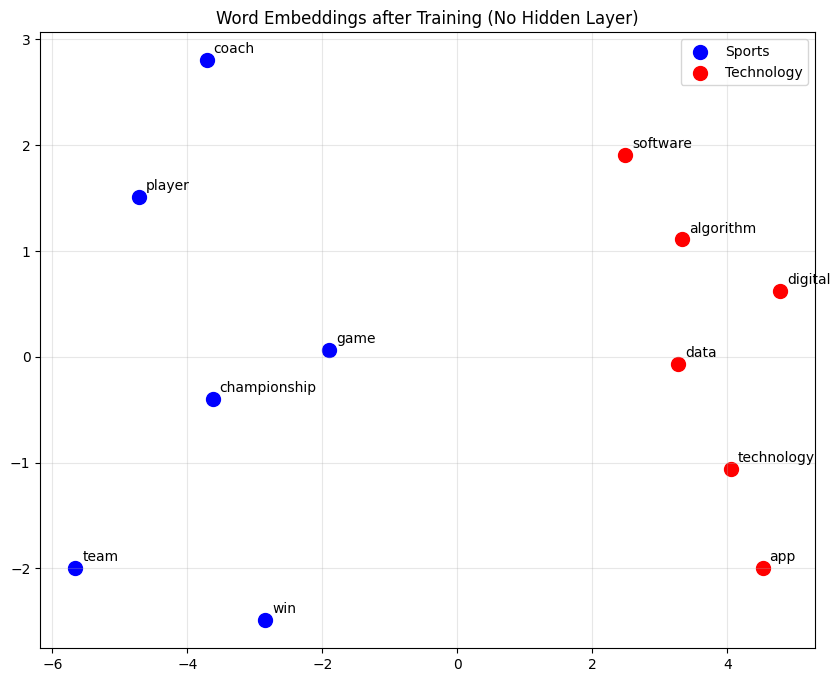

In [11]:
def calculate_cosine_sim(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

final_vectors = {}
for w in words_to_track:
    final_vectors[w] = get_embedding_vector(w, model, word_to_ix)

print("\n--- Improvement Analysis ---")

# Compare Team vs Game (Should increase)
sim_start = calculate_cosine_sim(initial_vectors["team"], initial_vectors["game"])
sim_end = calculate_cosine_sim(final_vectors["team"], final_vectors["game"])
print(f"Similarity 'team' vs 'game':\n  Start: {sim_start:.4f}\n  End:   {sim_end:.4f} (Expect Increase)")

# Compare Team vs Software (Should decrease or stay low)
sim_start_bad = calculate_cosine_sim(initial_vectors["team"], initial_vectors["software"])
sim_end_bad = calculate_cosine_sim(final_vectors["team"], final_vectors["software"])
print(f"Similarity 'team' vs 'software':\n  Start: {sim_start_bad:.4f}\n  End:   {sim_end_bad:.4f} (Expect Low/Negative)")


# --- Visualization ---
sports_words = ["team", "game", "championship", "win", "player", "coach"]
tech_words = ["software", "technology", "algorithm", "digital", "data", "app"]
vis_words = sports_words + tech_words

vectors = []
labels = []

for w in vis_words:
    if w in word_to_ix:
        vectors.append(get_embedding_vector(w, model, word_to_ix))
        labels.append(w)

pca = PCA(n_components=2)
reduced = pca.fit_transform(np.array(vectors))

plt.figure(figsize=(10, 8))
# Sports points
plt.scatter(reduced[:len(sports_words), 0], reduced[:len(sports_words), 1], color='blue', label='Sports', s=100)
# Tech points
plt.scatter(reduced[len(sports_words):, 0], reduced[len(sports_words):, 1], color='red', label='Technology', s=100)

for i, txt in enumerate(labels):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), xytext=(5, 5), textcoords='offset points')

plt.title("Word Embeddings after Training (No Hidden Layer)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()